In [1]:
from skimage import transform, io
import matplotlib.pyplot as plt
import os
import numpy as np
from skimage.color import rgb2gray
import random
import tensorflow as tf

In [2]:
def load_data(data_directory):
    if not os.path.exists(data_directory):
        raise FileNotFoundError(f"Data directory not found: {data_directory}")
    
    directories = [d for d in os.listdir(data_directory) 
                   if os.path.isdir(os.path.join(data_directory, d))]
    labels = []
    images = []
    for d in sorted(directories):
        label_directory = os.path.join(data_directory, d)
        file_names = [os.path.join(label_directory, f) for f in os.listdir(label_directory)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        for f in file_names:
            try:
                images.append(io.imread(f))
                labels.append(d)
            except Exception as e:
                print(f"Error loading {f}: {e}")
    return images, labels

ROOT_PATH = r"D:\Sign Language Detection\Hand-Sign-Datasets"
PROJECT_PATH = os.path.join(ROOT_PATH, "project")
TRAIN_PATH = os.path.join(ROOT_PATH, "train")
TEST_PATH = os.path.join(ROOT_PATH, "test")

train_data_directory = TRAIN_PATH

images, labels = load_data(train_data_directory)

unique_labels = sorted(set(labels))
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {idx: label for label, idx in label_to_index.items()}
labels = np.array([label_to_index[label] for label in labels], dtype=np.int32)


In [3]:
print("Total number of images:", len(images))
print("Total No of classes:", len(unique_labels))
print("Label Array:", unique_labels)
print("Sample image shape:", images[0].shape)


Total number of images: 4852
Total No of classes: 24
Label Array: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Sample image shape: (480, 640, 3)


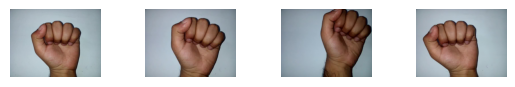

In [4]:
# Determine random indexes of images within dataset bounds
num_images = len(images)
hand_signs = [min(12, num_images-1), min(45, num_images-1), min(65, num_images-1), min(35, num_images-1)]
hand_signs = [i for i in hand_signs if i >= 0]

# Fill out the subplots with the random images that you defined 
for i in range(len(hand_signs)):
    plt.subplot(1, min(4, len(hand_signs)), i+1)
    plt.axis('off')
    plt.imshow(images[hand_signs[i]])
    plt.subplots_adjust(wspace=0.5)

plt.show()


Index 300 - shape: (480, 640, 3), min: 0, max: 221
Index 1250 - shape: (480, 640, 3), min: 0, max: 255
Index 2650 - shape: (480, 640, 3), min: 0, max: 255
Index 3000 - shape: (480, 640, 3), min: 0, max: 223


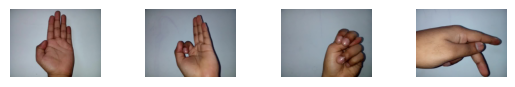

In [5]:
# Determine the (random) indexes of the images within dataset bounds
num_images = len(images)
hand_signs = [min(300, num_images-1), min(1250, num_images-1), min(2650, num_images-1), min(3000, num_images-1)]
hand_signs = [i for i in hand_signs if i >= 0]

# Fill out the subplots with the random images and add shape, min and max values
for i in range(len(hand_signs)):
    plt.subplot(1, min(4, len(hand_signs)), i+1)
    plt.axis('off')
    plt.imshow(images[hand_signs[i]])
    plt.subplots_adjust(wspace=0.5)
    print("Index {0} - shape: {1}, min: {2}, max: {3}".format(hand_signs[i],
                                                              images[hand_signs[i]].shape, 
                                                              images[hand_signs[i]].min(), 
                                                              images[hand_signs[i]].max()))

plt.show()


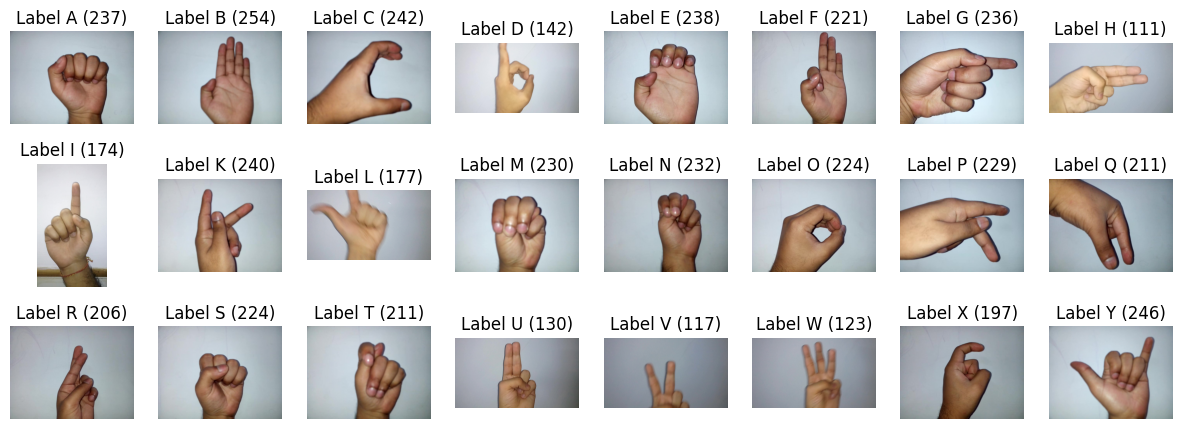

In [6]:
# Get the unique labels (already sorted from cell 2)
# Note: unique_labels and index_to_label are already defined in cell 2

# Initialize the figure
plt.figure(figsize=(15, 15))

# Set a counter
i = 1

# For each unique label,
for label_str in unique_labels:
    # Convert string label to numeric index
    label_idx = label_to_index[label_str]
    # You pick the first image for each label
    image = images[np.where(labels == label_idx)[0][0]]
    # Define 64 subplots 
    plt.subplot(8, 8, i)
    # Don't include axes
    plt.axis('off')
    # Add a title to each subplot 
    label_count = np.sum(labels == label_idx)
    plt.title("Label {0} ({1})".format(index_to_label[label_idx], label_count))
    # Add 1 to the counter
    i += 1
    # And you plot this first image 
    plt.imshow(image)
    
# Show the plot
plt.show()


# Feature Extraction

In [7]:
%pip install opencv-python
import cv2

# Check if images are loaded
if 'images' not in locals():
	print("Error: images not defined. Please run cell 1 (load_data) first!")
else:
	# Significantly faster:
	images32 = np.array([cv2.resize(img, (28, 28)) for img in images])
	print("Shape after resize:", images32.shape)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape after resize: (4852, 28, 28, 3)


# Image Conversion to Grayscale

In [8]:
if 'images32' not in locals():
	print("Error: images32 not defined. Please run cell 7 (resizing) first!")
else:
	images32 = rgb2gray(images32)
	print("Shape after grayscale:", images32.shape)


Shape after grayscale: (4852, 28, 28)


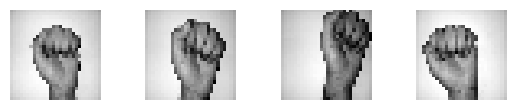

Grayscale images shape: (4852, 28, 28)


In [9]:
# Display some example grayscale images with valid indices
if 'images32' not in locals():
    print("Error: images32 not defined. Please run cells 7-9 (resizing and grayscale conversion) first!")
else:
    num_images = len(images32)
    display_indexes = [min(12, num_images-1), min(45, num_images-1), min(65, num_images-1), min(35, num_images-1)]
    display_indexes = [i for i in display_indexes if i >= 0]

    for i in range(len(display_indexes)):
        plt.subplot(1, min(4, len(display_indexes)), i+1)
        plt.axis('off')
        plt.imshow(images32[display_indexes[i]], cmap="gray")
        plt.subplots_adjust(wspace=0.5)
        
    plt.show()

    print("Grayscale images shape:", images32.shape)


# Model

In [10]:
if 'images32' not in locals():
    print("Error: images32 not defined. Please run cells 0-10 first (data loading, resizing, and grayscale conversion)!")
elif 'unique_labels' not in locals() or 'labels' not in locals():
    print("Error: unique_labels or labels not defined. Please run cell 1 first!")
else:
    # Reshape grayscale images to add channel dimension
    if len(images32.shape) == 3:
        # Shape is (N, 28, 28), add channel dimension
        images32 = images32.reshape(-1, 28, 28, 1).astype(np.float32)
    else:
        # Shape already has 4 dimensions, just ensure proper dtype
        images32 = images32.astype(np.float32)

    num_classes = len(unique_labels)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPool2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPool2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("Model created successfully!")
    model.summary()


Model created successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
if 'model' not in locals():
    print("Error: Model not defined. Please run cell 12 first!")
else:
    history = model.fit(
        images32,
        labels,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        verbose=2
    )


Epoch 1/20
137/137 - 2s - 14ms/step - accuracy: 0.2987 - loss: 2.3233 - val_accuracy: 0.0000e+00 - val_loss: 16.4814
Epoch 2/20
137/137 - 1s - 5ms/step - accuracy: 0.6945 - loss: 0.9817 - val_accuracy: 0.0062 - val_loss: 23.1981
Epoch 3/20
137/137 - 1s - 6ms/step - accuracy: 0.8301 - loss: 0.5492 - val_accuracy: 0.0082 - val_loss: 23.6000
Epoch 4/20
137/137 - 1s - 5ms/step - accuracy: 0.9004 - loss: 0.3250 - val_accuracy: 0.0041 - val_loss: 30.8230
Epoch 5/20
137/137 - 1s - 5ms/step - accuracy: 0.9306 - loss: 0.2249 - val_accuracy: 0.0206 - val_loss: 30.9379
Epoch 6/20
137/137 - 1s - 5ms/step - accuracy: 0.9622 - loss: 0.1446 - val_accuracy: 0.0165 - val_loss: 32.0434
Epoch 7/20
137/137 - 1s - 5ms/step - accuracy: 0.9787 - loss: 0.0936 - val_accuracy: 0.0226 - val_loss: 38.1230
Epoch 8/20
137/137 - 1s - 6ms/step - accuracy: 0.9785 - loss: 0.0799 - val_accuracy: 0.0185 - val_loss: 36.9668
Epoch 9/20
137/137 - 1s - 6ms/step - accuracy: 0.9899 - loss: 0.0500 - val_accuracy: 0.0185 - val_l

# Evaluation

In [12]:
if 'model' not in locals():
    print("Error: Model not defined. Please run cell 12 (model creation) and cell 13 (model training) first!")
elif 'images32' not in locals():
    print("Error: images32 not defined. Please run cells 7-9 (resizing and grayscale conversion) first!")
else:
    # Pick 10 random images
    if len(images32) >= 10:
        sample_indexes = random.sample(range(len(images32)), 10)
    else:
        sample_indexes = range(len(images32))
        
    sample_images = images32[sample_indexes]
    sample_labels = labels[sample_indexes]

    # Run the model prediction
    predicted_probs = model.predict(sample_images, verbose=0)
    predicted = np.argmax(predicted_probs, axis=1)

    # Print the real and predicted labels
    print("Real labels:", [index_to_label[i] for i in sample_labels])
    print("Predicted labels:", [index_to_label[i] for i in predicted])


Real labels: ['Q', 'C', 'W', 'S', 'Q', 'E', 'Y', 'T', 'M', 'P']
Predicted labels: ['Q', 'C', 'V', 'S', 'Q', 'E', 'B', 'T', 'M', 'P']


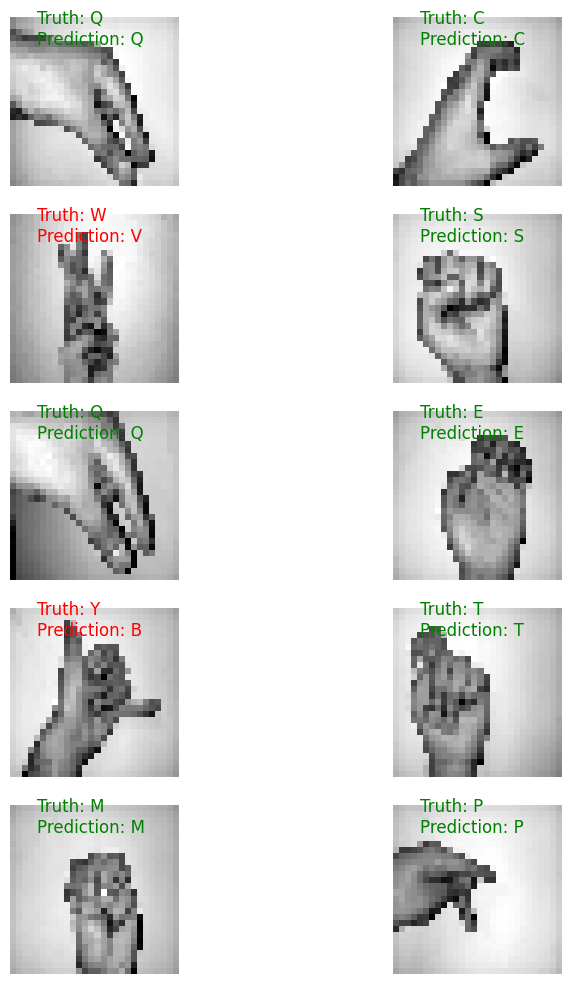

In [13]:
# Display the predictions and the ground truth visually.
# Make sure required variables are defined
if 'sample_images' not in locals() or 'sample_labels' not in locals() or 'predicted' not in locals():
    print("Error: Please run cell 15 (model evaluation) first!")
else:
    fig = plt.figure(figsize=(10, 10))
    for i in range(len(sample_images)):
        truth = index_to_label[sample_labels[i]]
        prediction = index_to_label[predicted[i]]
        plt.subplot(5, 2, 1 + i)
        plt.axis('off')
        color = 'green' if truth == prediction else 'red'
        plt.text(4, 4, "Truth: {0}\nPrediction: {1}".format(truth, prediction), 
                 fontsize=12, color=color)
        # Squeeze to remove channel dimension for display
        img_display = sample_images[i].squeeze()
        plt.imshow(img_display, cmap='gray')

    plt.tight_layout()
    plt.show()


In [14]:
# Optional: Load and evaluate on test data
test_data_directory = TEST_PATH

try:
    test_images, test_labels = load_data(test_data_directory)
    
    if len(test_images) > 0:
        # Convert test labels to numeric indices
        test_labels = np.array([label_to_index[label] for label in test_labels], dtype=np.int32)
        
        # Preprocess test images (resize and grayscale)
        test_images_resized = [transform.resize(img, (28, 28, 3)) for img in test_images]
        test_images_resized = np.array(test_images_resized)
        test_images_gray = rgb2gray(test_images_resized)
        test_images_gray = test_images_gray.reshape(-1, 28, 28, 1).astype(np.float32)
        
        # Evaluate on test set
        test_loss, test_accuracy = model.evaluate(test_images_gray, test_labels, verbose=0)
        print(f"\nTest Set Results:")
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test Accuracy: {test_accuracy:.4f}")
    else:
        print("No test images found in test directory")
except Exception as e:
    print(f"Could not load test data: {e}")



Test Set Results:
Test Loss: 38.3074
Test Accuracy: 0.0637


In [15]:
# Optional: Save model for deployment
model_save_path = os.path.join(PROJECT_PATH, "sign_language_model.h5")

try:
    # Create project directory if it doesn't exist
    os.makedirs(PROJECT_PATH, exist_ok=True)
    
    # Save the trained model
    model.save(model_save_path)
    print(f"Model saved to: {model_save_path}")
    
    # Save label mappings for later use
    import json
    mappings = {
        'label_to_index': label_to_index,
        'index_to_label': {str(k): v for k, v in index_to_label.items()}
    }
    mappings_path = os.path.join(PROJECT_PATH, "label_mappings.json")
    with open(mappings_path, 'w') as f:
        json.dump(mappings, f, indent=2)
    print(f"Label mappings saved to: {mappings_path}")
    
except Exception as e:
    print(f"Could not save model: {e}")


Model saved to: D:\Sign Language Detection\Hand-Sign-Datasets\project\sign_language_model.h5
Label mappings saved to: D:\Sign Language Detection\Hand-Sign-Datasets\project\label_mappings.json


In [16]:
# TensorFlow 2.x manages sessions automatically, no need to close manually
print("Model training and evaluation complete!")

Model training and evaluation complete!
